# 03 — LLM-Powered Semantic Target Extraction

## Overview

This notebook walks through every stage of the LLM-based extraction pipeline for EarningsLens:
the prompt design, single-call experiments, comparison with spaCy, prompt-variant ablations,
batch processing via the `LLMTargetExtractor` class, long-transcript handling, error handling,
cost estimation, and a full-corpus run.

---

## Why LLMs Instead of spaCy NER?

The spaCy baseline in `src/baseline/target_extractor.py` uses NER entity labels
(`MONEY`, `PERCENT`, `PRODUCT`, `CARDINAL`, `QUANTITY`) combined with dependency-parsed
"goal verb" triggers (`achieve`, `target`, `maintain`, …) to identify performance targets.
This replicates the Cohen & Nguyen (2024) methodology and works well for clean, numerical targets.

However, it has three systematic blind spots that degrade the **Moving Targets (MT)** signal:

1. **Syntactic fragility** — the three-criterion rule (NER + nummod + goal-verb) must fire
   simultaneously in the same dependency subtree. Any syntactic variation breaks it. A sentence
   like *"double-digit cloud growth, consistent with prior quarters"* contains no `MONEY` or
   `PERCENT` entity, so spaCy emits nothing.

2. **False-positive drops from rephrasing** — when management says *"comparable-store sales
   momentum"* in Q2 instead of *"same-store sales growth"* in Q1, exact-string matching flags
   the Q1 target as *dropped* even though the KPI is unchanged. This injects noise into the MT
   measure, biasing return-predictability tests.

3. **No contextual reasoning** — spaCy cannot interpret implicit commitments (*"we see no reason
   that trajectory changes"*) or recognize that 2 billion active devices is a tracked operational
   target even though it is a `CARDINAL`, not a `MONEY`, entity.

GPT-4o-mini with a chain-of-thought extraction prompt addresses all three: it reasons about
management intent, normalizes synonymous phrasings into canonical metric names, and flags
trend-based commitments without explicit numeric anchors.

In [1]:
import os
from pathlib import Path

from dotenv import load_dotenv

# Load OPENAI_API_KEY (and any other secrets) from .env at the project root.
# NEVER paste a literal key into this notebook — keys committed to git must be
# treated as compromised and rotated.
_DOTENV_CANDIDATES = [
    Path.cwd() / ".env",
    Path.cwd().parent / ".env",
    Path.cwd().parent.parent / ".env",
]
for _p in _DOTENV_CANDIDATES:
    if _p.exists():
        load_dotenv(_p, override=False)
        break

assert os.environ.get("OPENAI_API_KEY"), (
    "OPENAI_API_KEY missing. Add it to the project's .env file."
)

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Setup: imports, environment variables, and path configuration
# ─────────────────────────────────────────────────────────────────────────────
import asyncio
import importlib
import json
import logging
import os
import re
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import openai
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns
from tqdm.auto import tqdm

# ── Project root on sys.path ──────────────────────────────────────────────────
CANDIDATE_ROOTS = [
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
    Path.cwd().resolve().parent.parent,
]
REPO_ROOT = next(
    (c for c in CANDIDATE_ROOTS
     if (c / "src").exists() and ((c / "data").exists() or (c / "Data").exists())),
    Path("../").resolve(),
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# ── Logging (silence noisy transport loggers) ─────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(name)s  %(message)s",
    datefmt="%H:%M:%S",
)
for _noisy in ("httpx", "httpcore", "openai._base_client", "urllib3"):
    logging.getLogger(_noisy).setLevel(logging.WARNING)
logger = logging.getLogger("nb03")

# ── OpenAI key (loaded by Cell 1 from .env) ──────────────────────────────────
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")
if not OPENAI_API_KEY:
    raise RuntimeError(
        "OPENAI_API_KEY missing. Set it in the project .env file before running."
    )

# ── Data paths (resolve case-insensitively for macOS) ────────────────────────
DATA_ROOT = REPO_ROOT / "Data" if (REPO_ROOT / "Data").exists() else REPO_ROOT / "data"
DATA_RAW = DATA_ROOT / "raw"
DATA_PROCESSED = DATA_ROOT / "processed"
DATA_CACHE = DATA_ROOT / "cache"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
DATA_CACHE.mkdir(parents=True, exist_ok=True)

print(f"REPO_ROOT      : {REPO_ROOT}")
print(f"DATA_ROOT      : {DATA_ROOT}")
print(f"DATA_PROCESSED : {DATA_PROCESSED}")
print(f"OPENAI key     : loaded ({len(OPENAI_API_KEY)} chars)")

REPO_ROOT      : /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project
DATA_ROOT      : /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/Data
DATA_PROCESSED : /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/Data/processed
OPENAI key     : loaded (164 chars)


/Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Load transcript components.
#
# Sampling strategy (fixed to enable Moving Targets computation):
#
# The Moving Targets measure MT_{i,t} = |T_{i,t-4} \ T_{i,t}| / |T_{i,t-4}|
# requires year-over-year target sets per firm. The previous version of this
# cell sampled the first 200 transcript IDs from row-group-0 of the parquet,
# which only covered 2010 Q1 — making MT undefined.
#
# Fix: align the LLM panel with the spaCy baseline panel that 02_spacy_baseline
# already produced. We read the (companyid, fiscalyear, fiscalquarter) keys
# spaCy covers, then load exactly those transcripts from the CIQ parquet.
# This guarantees apples-to-apples comparability in Section 10.
#
# If the spaCy parquet is missing, we fall back to a stratified random sample
# of N firms × all available quarters — still multi-year, never single-quarter.
# ─────────────────────────────────────────────────────────────────────────────
SAMPLE_FIRMS_FALLBACK = 30   # used only if spaCy panel is missing
SEED = 42

ciq_path_candidates = [
    DATA_RAW / "ciq_transcripts.parquet",
    REPO_ROOT / "Data" / "ciq_transcripts.parquet",
    REPO_ROOT / "data" / "raw" / "ciq_transcripts.parquet",
]
ciq_path = next((p for p in ciq_path_candidates if p.exists()), None)
if ciq_path is None:
    raise FileNotFoundError("ciq_transcripts.parquet not found in DATA_RAW or DATA_ROOT.")

spacy_targets_path = DATA_PROCESSED / "spacy_targets.parquet"

USE_COLS = [
    "companyid", "transcriptid", "componenttypeid", "componenttext",
    "call_date", "transcriptcomponentid", "componentorder",
]
COMPONENT_TYPES = [2, 3, 4]   # Presentation, Question, Answer (per CIQ schema)

if spacy_targets_path.exists():
    sp = pd.read_parquet(
        spacy_targets_path, columns=["companyid", "fiscalyear", "fiscalquarter"]
    )
    panel_keys = (
        sp.dropna(subset=["companyid", "fiscalyear", "fiscalquarter"])
          .astype({"companyid": "Int64", "fiscalyear": "Int64", "fiscalquarter": "Int64"})
          .drop_duplicates()
    )
    target_company_ids = panel_keys["companyid"].astype(float).unique().tolist()
    sampling_strategy = (
        f"spaCy panel ({len(panel_keys):,} firm-quarters, "
        f"{panel_keys['companyid'].nunique()} firms, "
        f"{panel_keys['fiscalyear'].min()}-{panel_keys['fiscalyear'].max()})"
    )
else:
    pf = pq.ParquetFile(ciq_path)
    company_ids_seen: set[float] = set()
    for rg_idx in range(min(pf.num_row_groups, 8)):
        chunk = pf.read_row_group(rg_idx, columns=["companyid"]).to_pandas()
        company_ids_seen.update(chunk["companyid"].dropna().unique().tolist())
    rng = np.random.default_rng(SEED)
    sampled = rng.choice(
        sorted(company_ids_seen), size=min(SAMPLE_FIRMS_FALLBACK, len(company_ids_seen)),
        replace=False,
    )
    target_company_ids = sampled.tolist()
    panel_keys = None
    sampling_strategy = f"fallback random {len(target_company_ids)} firms"

print(f"Sampling strategy : {sampling_strategy}")
print(f"Companies to load : {len(target_company_ids):,}")
print(f"Loading from      : {ciq_path}")

raw_df = pd.read_parquet(
    ciq_path,
    columns=USE_COLS,
    filters=[
        ("componenttypeid", "in", COMPONENT_TYPES),
        ("companyid", "in", target_company_ids),
    ],
).rename(columns={"componenttypeid": "component_type", "componenttext": "text"})

raw_df["call_date"] = pd.to_datetime(raw_df["call_date"], errors="coerce")
raw_df = raw_df.dropna(subset=["call_date", "text"]).copy()
raw_df["fiscalyear"] = raw_df["call_date"].dt.year.astype(int)
raw_df["fiscalquarter"] = raw_df["call_date"].dt.quarter.astype(int)

# If we have an explicit panel from spaCy, restrict exactly to those firm-quarters.
if panel_keys is not None:
    panel_keys = panel_keys.astype({"companyid": "float64",
                                     "fiscalyear": "int64",
                                     "fiscalquarter": "int64"})
    raw_df = raw_df.merge(panel_keys, on=["companyid", "fiscalyear", "fiscalquarter"],
                          how="inner")

raw_df = raw_df.sort_values(
    ["companyid", "fiscalyear", "fiscalquarter", "componentorder"]
).reset_index(drop=True)

transcripts_df = raw_df

required_cols = ["companyid", "fiscalyear", "fiscalquarter", "component_type", "text"]
missing = [c for c in required_cols if c not in transcripts_df.columns]
if missing:
    raise ValueError(f"Input dataframe missing required columns: {missing}")

n_firms = transcripts_df["companyid"].nunique()
n_keys = transcripts_df.groupby(["companyid", "fiscalyear", "fiscalquarter"]).ngroups
yr_min = int(transcripts_df["fiscalyear"].min())
yr_max = int(transcripts_df["fiscalyear"].max())

print(f"Loaded {len(transcripts_df):,} component rows")
print(f"  firms                : {n_firms}")
print(f"  firm-quarters        : {n_keys}")
print(f"  year range           : {yr_min}-{yr_max}")
print(f"  component-type counts: {transcripts_df['component_type'].value_counts().to_dict()}")
print()
transcripts_df.head()

Sampling strategy : spaCy panel (929 firm-quarters, 26 firms, 2010-2023)
Companies to load : 26
Loading from      : /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/Data/ciq_transcripts.parquet
Loaded 221,259 component rows
  firms                : 26
  firm-quarters        : 929
  year range           : 2010-2023
  component-type counts: {np.int64(4): 113392, np.int64(3): 84812, np.int64(2): 23055}



,companyid,transcriptid,component_type,text,call_date,transcriptcomponentid,componentorder,fiscalyear,fiscalquarter
0,33926.0,46068.0,2,Good morning. Thank you for joining us today. ...,2010-01-15,3514406,2,2010,1
1,33926.0,54193.0,2,Good morning. Joining me on our call today are...,2010-03-19,4091083,2,2010,1
2,33926.0,54092.0,2,Good morning. Joining me on our call today are...,2010-03-18,4084511,2,2010,1
3,33926.0,54229.0,2,Good morning. Joining me on our call today are...,2010-03-20,4093274,2,2010,1
4,33926.0,45556.0,2,Good morning. Thank you for joining us today. ...,2010-01-11,3480016,2,2010,1


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Build a list of transcript dicts in the format expected by LLMTargetExtractor
# Each transcript_id groups the rows for one (companyid, fiscalyear, fiscalquarter).
# ─────────────────────────────────────────────────────────────────────────────
def build_transcript_list(df: pd.DataFrame) -> list:
    """
    Convert the raw transcript DataFrame into the dict format consumed by
    LLMTargetExtractor.extract_corpus():

        [
          {
            "transcript_id": "AAPL_2022Q1",
            "company_id"   : "AAPL",
            "quarter"      : "2022Q1",
            "components"   : [
              {"text": "...", "component_type": 2},
              {"text": "...", "component_type": 4},
            ]
          },
          ...
        ]
    """
    transcripts = []
    for (company, year, quarter), group in df.groupby(
        ["companyid", "fiscalyear", "fiscalquarter"]
    ):
        tid = f"{company}_{year}Q{quarter}"
        components = [
            {"text": row["text"], "component_type": int(row["component_type"])}
            for _, row in group.iterrows()
        ]
        transcripts.append(
            {
                "transcript_id": tid,
                "company_id"   : company,
                "quarter"      : f"{year}Q{quarter}",
                "components"   : components,
            }
        )
    return transcripts


sample_transcripts = build_transcript_list(transcripts_df)

print(f"Built {len(sample_transcripts)} transcript dicts")
print("First transcript:")
t0 = sample_transcripts[0]
print(f"  transcript_id : {t0['transcript_id']}")
print(f"  components    : {len(t0['components'])} (types: {[c['component_type'] for c in t0['components']]})")
print(f"  text snippet  : {t0['components'][0]['text'][:120]}...")

Built 929 transcript dicts
First transcript:
  transcript_id : 33926.0_2010Q1
  components    : 552 (types: [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 4, 4, 4, 3, 3, 4, 4, 4, 3, 4, 4, 3, 3, 3, 4, 4, 3, 3, 4, 3, 3, 4, 4, 3, 3, 3, 4, 4, 3, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 4, 4, 3, 4, 4, 3, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 4, 3, 3, 4, 4, 3, 3, 3, 4, 4, 3, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 4, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 3, 3, 4, 3, 4, 4, 4, 4, 4, 4, 3, 4, 4, 3, 3, 3, 4, 4, 3, 3, 4, 3, 3, 4, 4, 3, 3, 3, 4, 4, 3, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 4, 4, 3, 4, 4, 3, 3, 4, 4, 4, 3, 3, 4, 3, 4, 4, 3, 3, 3, 4, 4, 3, 3, 3, 4, 3, 3, 4, 4, 4, 3, 3, 4, 4, 3, 4, 4, 3, 4, 4, 4, 4, 3, 3, 3, 3, 4, 4, 3, 4, 4, 3, 3, 3, 4, 4, 3, 3, 4, 3, 3, 4, 4, 

---

## Section 1: Understanding the Prompts

The extraction pipeline relies on three prompt objects defined in `src/llm_extraction/prompts.py`:

| Prompt | Purpose |
|---|---|
| `SYSTEM_PROMPT` | Sets the LLM's persona as a senior financial analyst and constrains output to valid JSON only. |
| `EXTRACTION_PROMPT` | Drives chain-of-thought extraction via three explicit reasoning stages before the final JSON output. |
| `FEW_SHOT_EXAMPLES` | Provides three labeled examples that specifically target the spaCy blind spots described above. |
| `CONTINUITY_CHECK_PROMPT` | Used as a fallback in RAG deduplication: given two target descriptions, decides whether they refer to the same KPI. |

### Chain-of-Thought Design Philosophy

The three-stage CoT structure forces the model to work bottom-up:

1. **Stage 1 — Enumerate all metrics**: list everything mentioned regardless of whether it has a number.  
   This prevents the model from skipping targets that *feel* non-quantitative.

2. **Stage 2 — Classify**: for each metric, decide whether management has made a commitment
   (tracked target) or merely mentioned it in passing. This is where contextual reasoning kicks in.

3. **Stage 3 — Structured JSON**: only after the reasoning is done does the model emit output.
   This separates the *thinking* from the *formatting* step, which is critical for JSON fidelity.

The key engineering choice is `temperature=0.0` with `response_format={"type": "json_object"}`.  
Both settings together maximize determinism and eliminate the risk of prose contaminating the JSON output.

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Print and annotate SYSTEM_PROMPT
# ─────────────────────────────────────────────────────────────────────────────
from src.llm_extraction.prompts import (
    SYSTEM_PROMPT,
    EXTRACTION_PROMPT,
    FEW_SHOT_EXAMPLES,
    CONTINUITY_CHECK_PROMPT,
)

print("=" * 70)
print("SYSTEM_PROMPT")
print("=" * 70)
print(SYSTEM_PROMPT)

print("\nKey design observations:")
print("  [1] Persona: 'senior financial analyst' — anchors the model in the domain.")
print("  [2] Hard output guardrail: JSON-only + no prose outside JSON.")
print("      This is critical for stable parsing in downstream code.")
print("  [3] Explicit empty-output behavior: return {'targets': []} when none found.")
print("      This reduces hallucinated targets in irrelevant transcript segments.")
print("  [4] Broader semantic coverage is mainly enforced by EXTRACTION_PROMPT")
print("      stages and FEW_SHOT_EXAMPLES (not SYSTEM_PROMPT alone).")

SYSTEM_PROMPT
You are a senior financial analyst extracting performance targets from earnings call transcript components. Return only the structured JSON specified by the schema. If no targets are present, return an empty targets array.

Key design observations:
  [1] Persona: 'senior financial analyst' — anchors the model in the domain.
  [2] Hard output guardrail: JSON-only + no prose outside JSON.
      This is critical for stable parsing in downstream code.
  [3] Explicit empty-output behavior: return {'targets': []} when none found.
      This reduces hallucinated targets in irrelevant transcript segments.
  [4] Broader semantic coverage is mainly enforced by EXTRACTION_PROMPT
      stages and FEW_SHOT_EXAMPLES (not SYSTEM_PROMPT alone).


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Print EXTRACTION_PROMPT skeleton (without few-shot block) and annotate stages
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("EXTRACTION_PROMPT (skeleton — {transcript_text} and {few_shot_examples} are placeholders)")
print("=" * 70)
print(EXTRACTION_PROMPT)

print("\nAnnotation:")
print("  Stage 1 — Enumerate ALL metrics, numeric or qualitative.")
print("            This helps capture qualitative commitments that spaCy can miss.")
print()
print("  Stage 2 — Keep TRACKED TARGETS / GUIDANCE, drop CASUAL MENTIONS.")
print("            Signal cues include values, trend direction, thresholds, and")
print("            explicit or implicit management commitments.")
print()
print("  Stage 3 — Emit strict JSON with required fields.")
print("            Key schema fields: metric_name, raw_text, numerical_value,")
print("            trend_direction, unit, time_horizon, confidence.")
print("            time_horizon values: current/forward/historical/unknown.")

EXTRACTION_PROMPT (skeleton — {transcript_text} and {few_shot_examples} are placeholders)
Extract performance targets from the transcript component below.

Stage 1: Enumerate every business metric that appears (numeric or qualitative).
Stage 2: Keep only metrics that represent tracked performance targets or guidance;
         drop incidental mentions and analyst commentary.
Stage 3: Emit the JSON object specified by the schema. Do not output prose.

Component type: {component_type_id} ({component_type_label})

Few-shot examples:
{few_shot_examples}

Transcript text:
{transcript_text}


Annotation:
  Stage 1 — Enumerate ALL metrics, numeric or qualitative.
            This helps capture qualitative commitments that spaCy can miss.

  Stage 2 — Keep TRACKED TARGETS / GUIDANCE, drop CASUAL MENTIONS.
            Signal cues include values, trend direction, thresholds, and
            explicit or implicit management commitments.

  Stage 3 — Emit strict JSON with required fields.
          

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Print the three few-shot examples and explain each one's role
# ─────────────────────────────────────────────────────────────────────────────
print(FEW_SHOT_EXAMPLES)

print("\n=" * 70)
print("Why these three examples?")
print("=" * 70)
print("""
Example 1 — Mixed qualitative + quantitative guidance:
  'double-digit subscription growth' teaches the model to keep an important
  target even when numerical_value is null, while 'expand 150 bps' anchors a
  concrete numeric guidance target in the same sentence.

Example 2 — Threshold-style forward commitment:
  'operating margin above 20% through FY2026' teaches boundary constraints
  (above/below) with a forward horizon, not just point estimates.

Example 3 — Operational KPI bundle in one sentence:
  'device activations reached 2 million' plus 'churn improved sequentially'
  teaches multi-target extraction with different units and trend directions
  (count/up vs churn/down).
""")

[{'component_type': 2, 'transcript_text': 'We maintained double-digit subscription growth and expect gross margin to expand 150 basis points next year.', 'targets': [{'metric_name': 'subscription growth', 'raw_text': 'double-digit subscription growth', 'numerical_value': None, 'trend_direction': 'up', 'unit': 'percent', 'time_horizon': 'current', 'is_financial': False, 'confidence': 'high'}, {'metric_name': 'gross margin', 'raw_text': 'expand 150 basis points next year', 'numerical_value': 150, 'trend_direction': 'up', 'unit': 'bps', 'time_horizon': 'forward', 'is_financial': True, 'confidence': 'high'}]}, {'component_type': 4, 'transcript_text': 'We expect operating margin to remain above 20% through FY2026.', 'targets': [{'metric_name': 'operating margin', 'raw_text': 'remain above 20% through FY2026', 'numerical_value': 20, 'trend_direction': 'flat', 'unit': 'percent', 'time_horizon': 'forward', 'is_financial': True, 'confidence': 'high'}]}, {'component_type': 2, 'transcript_text': 

---

## Section 2: Single-Call Experiment

Before using the full `LLMTargetExtractor` class, let's manually construct one API call
so we can inspect every part of the request and response.  This is the fastest way to
verify that the prompt is working as expected.

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Load one sample transcript text for experiments
# Prefer a component that actually contains KPIs/guidance (not the operator intro).
#
# Component types per the CIQ schema (and Cohen & Nguyen 2024):
#   1 = Press Release     2 = Presentation
#   3 = Analyst Question  4 = Management Answer
# We rank Presentation (2) highest because that is where management states most
# guidance, then Management Answers (4), then Questions (3).
# ─────────────────────────────────────────────────────────────────────────────
from src.llm_extraction.prompts import (
    COMPONENT_TYPE_LABELS, COMPONENT_TYPE_PRIORITY,
)

sample_transcript = sample_transcripts[0]
components = sample_transcript["components"]


def _kpi_signal_score(text: str) -> int:
    t = text.lower()
    patterns = (
        r"\d+\s*%",
        r"\d+(\.\d+)?\s*bps",
        r"basis\s+points?",
        r"\$[\d,]+(\.\d+)?\s*(million|billion|m|bn)?",
        r"\b(revenue|margin|eps|ebitda|growth|guidance|outlook|forecast)\b",
        r"\b(double|single)[- ]digit\b",
    )
    return sum(1 for pat in patterns if re.search(pat, t))


def _numeric_bonus(text: str) -> int:
    t = text.lower()
    b = 0
    if re.search(r"\d", t):
        b += 1
    if re.search(r"\d+\s*%|\d+(\.\d+)?\s*%", t):
        b += 4
    if re.search(r"basis\s+points?|\d+\s*bps\b", t):
        b += 4
    if re.search(r"\$[\d,]+(\.\d+)?", t):
        b += 3
    if re.search(r"\b\d{1,3}(,\d{3})+\b", t):
        b += 2
    return b


def _analyst_question_penalty(text: str) -> int:
    """Down-rank analyst questions (often no numeric guidance) vs management answers."""
    t = text.strip().lower()
    pen = 0
    pen += 2 * t.count("?")
    if re.search(r"\b(do you|are you|can you|will you|could you|should we)\b", t):
        pen += 4
    if re.search(r"\b(what kind of|how much|how do you expect)\b", t):
        pen += 3
    if re.search(r"^i'?m looking at\b", t):
        pen += 3
    if re.search(r"\d+\s*%|\d+(\.\d+)?\s*bps|\$[\d,]+", t):
        pen = max(0, pen - 8)
    return pen


def _component_priority(comp: dict) -> tuple[int, int, int]:
    """Sort key: higher tuple is better.

    Order: KPI density first, then component-type rank (Presentation > Answer
    > Question > Press release), then text length.
    """
    text = comp.get("text") or ""
    if not text.strip():
        return (-10_000, 0, 0)
    ctype = int(comp.get("component_type", -1))
    type_rank = COMPONENT_TYPE_PRIORITY.get(ctype, 0)
    main = _kpi_signal_score(text) + _numeric_bonus(text) - _analyst_question_penalty(text)
    return (main, type_rank, len(text))


nonempty = [c for c in components if (c.get("text") or "").strip()]
sample_component = max(nonempty, key=_component_priority)

sample_text = sample_component["text"]
sample_ctype = sample_component["component_type"]

print(f"Transcript ID    : {sample_transcript['transcript_id']}")
print(f"Component type   : {sample_ctype} ({COMPONENT_TYPE_LABELS.get(sample_ctype, 'other')})")
print(f"Text length      : {len(sample_text)} characters")
print()
print("─" * 60)
print(sample_text)
print("─" * 60)

Transcript ID    : 33926.0_2010Q1
Component type   : 2 (presentation)
Text length      : 9322 characters

────────────────────────────────────────────────────────────
Good morning. Joining me on our call today are: Norman Ferber, Chairman of the Board; Michael O'Sullivan, President and Chief Operating Officer; Gary Cribb, Executive Vice President, Stores and Loss Prevention; John Call, Senior Vice President and Chief Financial Officer; and Bobbi Chaville, Senior Director, Investor Relations. We will begin today with a review of our fourth quarter and 2009 performance, followed by our outlook for 2010 and the longer term. Afterwards, we'll be happy to respond to any questions you may have.
Before we start, I want to note that our comments on this call will contain forward-looking statements regarding expectations about future growth and financial results and other matters that are based on management's current forecast of aspects of the company's future business. These forward-looking s

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Construct the full prompt manually to see exactly what the API will receive
# ─────────────────────────────────────────────────────────────────────────────
from src.llm_extraction.prompts import build_extraction_prompt

user_prompt = build_extraction_prompt(sample_text, sample_ctype)

print(f"System prompt length : {len(SYSTEM_PROMPT):,} chars")
print(f"User prompt length   : {len(user_prompt):,} chars")
print(f"Total request length : {len(SYSTEM_PROMPT) + len(user_prompt):,} chars")
print()
print("User prompt (first 800 chars):")
print(user_prompt[:800])
print("...")

System prompt length : 222 chars
User prompt length   : 11,732 chars
Total request length : 11,954 chars

User prompt (first 800 chars):
Extract performance targets from the transcript component below.

Stage 1: Enumerate every business metric that appears (numeric or qualitative).
Stage 2: Keep only metrics that represent tracked performance targets or guidance;
         drop incidental mentions and analyst commentary.
Stage 3: Emit the JSON object specified by the schema. Do not output prose.

Component type: 2 (presentation)

Few-shot examples:
[
  {
    "component_type": 2,
    "transcript_text": "We maintained double-digit subscription growth and expect gross margin to expand 150 basis points next year.",
    "targets": [
      {
        "metric_name": "subscription growth",
        "raw_text": "double-digit subscription growth",
        "numerical_value": null,
        "trend_direction": "up",
        "unit": "percent
...


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Call the OpenAI API directly — no class wrapper yet — so we can see the raw
# response object and measure token usage precisely.
# ─────────────────────────────────────────────────────────────────────────────
import openai

client = openai.OpenAI(api_key=OPENAI_API_KEY)

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": user_prompt},
    ],
    temperature=0.0,
    response_format={"type": "json_object"},
)

raw_response_text = response.choices[0].message.content
print("Raw API response:")
print(raw_response_text)

Raw API response:
{
  "component_type": 2,
  "transcript_text": "Good morning. Joining me on our call today are: Norman Ferber, Chairman of the Board; Michael O'Sullivan, President and Chief Operating Officer; Gary Cribb, Executive Vice President, Stores and Loss Prevention; John Call, Senior Vice President and Chief Financial Officer; and Bobbi Chaville, Senior Director, Investor Relations. We will begin today with a review of our fourth quarter and 2009 performance, followed by our outlook for 2010 and the longer term. Afterwards, we'll be happy to respond to any questions you may have. Before we start, I want to note that our comments on this call will contain forward-looking statements regarding expectations about future growth and financial results and other matters that are based on management's current forecast of aspects of the company's future business. These forward-looking statements are subject to risks and uncertainties that could cause our actual results to differ materia

In [12]:
parsed = json.loads(raw_response_text)

# Handle both possible shapes safely
targets = parsed.get("targets", []) if isinstance(parsed, dict) else parsed
targets_df = pd.DataFrame(targets)

print(f"Extracted {len(targets_df)} targets")
print("Columns:", list(targets_df.columns))
print()

pd.set_option("display.max_colwidth", 60)

cols_to_show = [
    c for c in [
        "metric_name", "numerical_value", "trend_direction",
        "unit", "time_horizon", "confidence"
    ] if c in targets_df.columns
]

display(targets_df[cols_to_show])

Extracted 3 targets
Columns: ['metric_name', 'raw_text', 'numerical_value', 'trend_direction', 'unit', 'time_horizon', 'is_financial', 'confidence']



,metric_name,numerical_value,trend_direction,unit,time_horizon,confidence
0,same-store sales,1.000,up,percent,forward,high
1,earnings per share,3.875,up,dollars,forward,high
2,earnings per share,NaN,up,percent,forward,medium


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Count tokens used and estimate cost for this single API call
# GPT-4o-mini pricing (April 2025): $0.15 / 1M input tokens, $0.60 / 1M output
# ─────────────────────────────────────────────────────────────────────────────
usage = response.usage

PRICE_INPUT_PER_1M  = 0.15   # USD, GPT-4o-mini
PRICE_OUTPUT_PER_1M = 0.60   # USD, GPT-4o-mini

cost_input  = (usage.prompt_tokens     / 1_000_000) * PRICE_INPUT_PER_1M
cost_output = (usage.completion_tokens / 1_000_000) * PRICE_OUTPUT_PER_1M
cost_total  = cost_input + cost_output

print(f"Token usage for this call:")
print(f"  Prompt tokens     : {usage.prompt_tokens:,}")
print(f"  Completion tokens : {usage.completion_tokens:,}")
print(f"  Total tokens      : {usage.total_tokens:,}")
print()
print(f"Estimated cost:")
print(f"  Input  : ${cost_input:.6f}")
print(f"  Output : ${cost_output:.6f}")
print(f"  TOTAL  : ${cost_total:.6f}")
print()
print(f"At this rate, 1,000 similar calls would cost ~${cost_total * 1000:.2f}")

Token usage for this call:
  Prompt tokens     : 2,589
  Completion tokens : 2,239
  Total tokens      : 4,828

Estimated cost:
  Input  : $0.000388
  Output : $0.001343
  TOTAL  : $0.001732

At this rate, 1,000 similar calls would cost ~$1.73


---

## Section 3: Comparing with spaCy

Now let's run the same transcript through the spaCy baseline and compare results side by side.
This comparison directly motivates the shift to LLM extraction.

In [14]:
from src.baseline.target_extractor import SpacyTargetExtractor
from src.llm_extraction.prompts import canonicalize_metric

spacy_extractor = SpacyTargetExtractor()
spacy_raw = spacy_extractor.extract_from_transcript([
    {"component_type": sample_ctype, "text": sample_text}
])

# Use the SAME canonicalisation function on both sides — otherwise
# "Gross Margin" (LLM) and "gross margin" (spaCy lemmatised) are treated as
# distinct strings and the intersection is empty by construction.
spacy_targets = {canonicalize_metric(r.get("target_text", "")) for r in spacy_raw}
spacy_targets.discard("")

llm_list = parsed.get("targets", []) if isinstance(parsed, dict) else parsed
llm_targets = {canonicalize_metric(str(t.get("metric_name", ""))) for t in llm_list}
llm_targets.discard("")

only_llm = llm_targets - spacy_targets
only_spacy = spacy_targets - llm_targets
both = llm_targets & spacy_targets

print(f"spaCy extracted     : {len(spacy_targets)} canonical targets")
print(f"LLM   extracted     : {len(llm_targets)} canonical targets")
print()
print(f"Found by BOTH       : {len(both)}     {sorted(both)[:5]}")
print(f"LLM only            : {len(only_llm)}    {sorted(only_llm)[:5]}")
print(f"spaCy only          : {len(only_spacy)}    {sorted(only_spacy)[:5]}")

spaCy extracted     : 13 canonical targets
LLM   extracted     : 2 canonical targets

Found by BOTH       : 0     []
LLM only            : 2    ['earning per share', 'sale same store']
spaCy only          : 13    ['1 10', '1 9', '11 7', '12 7', '20 basis point reduction']


**Interpretation:**  
The LLM typically captures more targets because it can extract trend-based and operationally-framed
metrics that have no `MONEY`/`PERCENT` spaCy entity.  The "spaCy only" group is usually empty or
contains very short fragments that the LLM correctly omits as non-committal mentions.

The difference is most pronounced for transcripts with forward guidance statements (component_type=3)
and Q&A sections (component_type=2), where management language tends to be qualitative.

---

## Section 4: Prompt Variations

To quantify how much each prompt engineering choice contributes, we run three ablations on the same
transcript and compare extraction quantity and quality:

1. **Zero-shot** — remove the three few-shot examples  
2. **No chain-of-thought** — replace the three-stage structure with a direct instruction  
3. **GPT-4o** — same full prompt, stronger model

This is a quick qualitative experiment; a rigorous ablation would need annotated ground truth.

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Helper: run one OpenAI call and return parsed targets + usage dict
# ─────────────────────────────────────────────────────────────────────────────
def run_extraction_variant(
    system_msg: str,
    user_msg: str,
    model: str = "gpt-4o-mini",
) -> tuple:
    """
    Returns (targets_list, usage_dict).
    targets_list is a list of dicts parsed from the LLM JSON response.
    """
    resp = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_msg},
            {"role": "user",   "content": user_msg},
        ],
        temperature=0.0,
        response_format={"type": "json_object"},
    )
    text = resp.choices[0].message.content
    parsed_r = json.loads(text)
    if isinstance(parsed_r, dict):
        for v in parsed_r.values():
            if isinstance(v, list):
                parsed_r = v
                break
    usage_dict = {
        "prompt_tokens"    : resp.usage.prompt_tokens,
        "completion_tokens": resp.usage.completion_tokens,
        "total_tokens"     : resp.usage.total_tokens,
    }
    return parsed_r, usage_dict

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Variant A: Zero-shot — no few-shot examples
# Remove FEW_SHOT_EXAMPLES from the prompt so the model must generalize from
# the Stage 1–3 instructions alone.
#
# EXTRACTION_PROMPT now expects two component-type placeholders so the model
# sees the human-readable label ("presentation", "management answer", …) in
# addition to the numeric code.
# ─────────────────────────────────────────────────────────────────────────────
zero_shot_prompt = EXTRACTION_PROMPT.format(
    transcript_text=sample_text,
    component_type_id=sample_ctype,
    component_type_label=COMPONENT_TYPE_LABELS.get(sample_ctype, "other"),
    few_shot_examples="",   # ← empty — zero-shot
)

targets_zero_shot, usage_zs = run_extraction_variant(SYSTEM_PROMPT, zero_shot_prompt)
print(f"Zero-shot: {len(targets_zero_shot)} targets extracted, "
      f"{usage_zs['total_tokens']} tokens")

KeyError: 'component_type_id'

In [42]:
# ─────────────────────────────────────────────────────────────────────────────
# Variant B: No chain-of-thought — direct extraction instruction.
# IMPORTANT: this variant must request the SAME field names as the main prompt
# (metric_name / raw_text / numerical_value / trend_direction / unit /
# time_horizon / is_financial / confidence). Earlier versions used a different
# schema (temporal_framing) which broke the comparison table in the next cell.
# ─────────────────────────────────────────────────────────────────────────────
NO_COT_PROMPT = """\
Extract all performance targets from the earnings call transcript segment below.
Return JSON of shape: {{"targets": [{{...}}]}}.
Each target object must have these keys:
  metric_name, raw_text, numerical_value, trend_direction, unit,
  time_horizon, is_financial, confidence

Transcript:
{transcript_text}

Output ONLY the JSON object.
"""

no_cot_prompt = NO_COT_PROMPT.format(transcript_text=sample_text)
targets_no_cot, usage_nc = run_extraction_variant(SYSTEM_PROMPT, no_cot_prompt)
print(f"No-CoT: {len(targets_no_cot)} targets extracted, "
      f"{usage_nc['total_tokens']} tokens")

17:03:35  INFO      httpx  HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


No-CoT: 9 targets extracted, 2464 tokens


In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# Variant C: GPT-4o (larger model) with the full prompt
# Compare extraction quality and token usage against GPT-4o-mini.
# Note: GPT-4o is ~10× more expensive, so we run this on one transcript only.
# ─────────────────────────────────────────────────────────────────────────────
targets_gpt4o, usage_4o = run_extraction_variant(
    SYSTEM_PROMPT, user_prompt, model="gpt-4o"
)
print(f"GPT-4o: {len(targets_gpt4o)} targets extracted, "
      f"{usage_4o['total_tokens']} tokens")

17:03:45  INFO      httpx  HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


GPT-4o: 7 targets extracted, 2791 tokens


In [45]:
# ─────────────────────────────────────────────────────────────────────────────
# Comparison table: all four variants side by side
# ─────────────────────────────────────────────────────────────────────────────
def _total_tokens(u) -> int:
    """OpenAI returns CompletionUsage (attrs); ablation helper returns dict."""
    if u is None:
        return 0
    if isinstance(u, dict):
        return int(u.get("total_tokens", 0))
    return int(getattr(u, "total_tokens", 0))


def _targets_as_list(obj):
    """First manual API call stores dict {\"targets\": [...]}; ablations return a list."""
    if isinstance(obj, dict):
        for v in obj.values():
            if isinstance(v, list):
                return v
        return []
    return obj if isinstance(obj, list) else []


VARIANTS = {
    "Full (few-shot + CoT, gpt-4o-mini)": _targets_as_list(parsed),
    "Zero-shot (no examples, gpt-4o-mini)": targets_zero_shot,
    "No-CoT (direct, gpt-4o-mini)"        : targets_no_cot,
    "Full prompt, GPT-4o"                  : targets_gpt4o,
}

USAGE = {
    "Full (few-shot + CoT, gpt-4o-mini)": usage,
    "Zero-shot (no examples, gpt-4o-mini)": usage_zs,
    "No-CoT (direct, gpt-4o-mini)"        : usage_nc,
    "Full prompt, GPT-4o"                  : usage_4o,
}

rows = []
for variant_name, targets_list in VARIANTS.items():
    u = USAGE[variant_name]
    if not targets_list:
        rows.append({"Variant": variant_name, "N targets": 0,
                     "N financial": 0, "N high conf": 0,
                     "Total tokens": _total_tokens(u)})
        continue
    df_v = pd.DataFrame(targets_list)
    rows.append({
        "Variant"      : variant_name,
        "N targets"    : len(df_v),
        "N financial"  : int(df_v.get("is_financial", pd.Series(dtype=bool)).sum()),
        "N high conf"  : int((df_v.get("confidence", pd.Series(dtype=str)) == "high").sum()),
        "Total tokens" : _total_tokens(u),
    })

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))
print()
print("Insight: CoT and few-shot examples typically increase target recall (N targets)")
print("and confidence distribution without dramatically increasing token usage.")
print("GPT-4o may catch additional nuanced targets but at a higher cost.")

                             Variant  N targets  N financial  N high conf  Total tokens
  Full (few-shot + CoT, gpt-4o-mini)          5            0            5          2611
Zero-shot (no examples, gpt-4o-mini)          7            0            7          2349
        No-CoT (direct, gpt-4o-mini)          9            9            9          2464
                 Full prompt, GPT-4o          7            0            5          2791

Insight: CoT and few-shot examples typically increase target recall (N targets)
and confidence distribution without dramatically increasing token usage.
GPT-4o may catch additional nuanced targets but at a higher cost.


---

## Section 5: Batch Extraction with the Class

The `LLMTargetExtractor` class wraps everything above into a clean async interface:

- **Component aggregation** — concatenates Presentation / Question / Answer
  components per transcript before chunking, collapsing ~80 Q&A turns into
  ~3 logical inputs.
- **Token-aware chunking** — uses `tiktoken` to keep chunks within
  `max_input_tokens_per_chunk` (default 12k tokens for GPT-4o-mini).
- **Structured Outputs** — uses OpenAI `chat.completions.parse` with the
  `TargetSet` Pydantic schema, eliminating regex-fallback JSON parsing.
- **Rate limiter + concurrency** — `aiolimiter` enforces an RPM cap so we can
  safely raise `max_concurrent` (e.g. 20–50) without 429s.
- **Resumable JSONL writer** — `extract_corpus_to_jsonl` appends one line per
  finished transcript and skips already-completed IDs on rerun.
- **Typed telemetry** — `http_failures`, `parse_failures`, `empty_responses`,
  `schema_invalid_drops`, `retries`, plus separate input/output token counts.

Run async calls with top-level `await`.

In [31]:
import src.llm_extraction.prompts as _prompts_mod
import src.llm_extraction.llm_extractor as _ext_mod
importlib.reload(_prompts_mod)
importlib.reload(_ext_mod)
from src.llm_extraction.llm_extractor import LLMTargetExtractor

extractor = LLMTargetExtractor(
    backend="openai",
    model="gpt-4o-mini",
    api_key=OPENAI_API_KEY,
    max_concurrent=20,            # was 5; the rate limiter prevents 429s
    temperature=0.0,
    max_input_tokens_per_chunk=12_000,
    request_timeout_s=90,
    max_retries=3,
    rpm_cap=4_500,                # well below the OpenAI tier-2 RPM ceiling
)

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# Process a batch of transcripts using extract_corpus()
# Top-level await runs on Jupyter's asyncio loop (required for httpx/sniffio).
# ─────────────────────────────────────────────────────────────────────────────
#BATCH_SIZE = min(10, len(sample_transcripts))   # cap at dataset size
BATCH_SIZE = 10

print(f"Processing {BATCH_SIZE} transcripts (max_concurrent=5)...")
corpus_results = await extractor.extract_corpus(sample_transcripts[:BATCH_SIZE], max_concurrent=5)

print(f"\nDone. Extracted targets for {len(corpus_results)} transcripts.")

Processing 10 transcripts (max_concurrent=5)...


23:51:33  INFO      httpx  HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
23:51:34  INFO      httpx  HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
23:51:34  INFO      httpx  HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
23:51:34  INFO      httpx  HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
23:51:40  INFO      httpx  HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
23:51:41  INFO      httpx  HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
23:51:46  INFO      httpx  HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
23:51:47  INFO      httpx  HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
23:51:50  INFO      httpx  HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
23:51:50  INFO      httpx  HTTP Reque


Done. Extracted targets for 10 transcripts.


In [33]:
for k, v in extractor.telemetry.items():
    print(f"  {k:24s} {v:,}")

{'total_tokens_used': 925677, 'total_requests': 1128, 'failed_requests': 0}


In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# Show telemetry: typed buckets distinguish HTTP failures from empty / parse drops.
# ─────────────────────────────────────────────────────────────────────────────
tel = extractor.telemetry
total = max(1, tel["total_requests"])
print("Telemetry after batch extraction:")
print(f"  Total requests          : {tel['total_requests']:,}")
print(f"  Input tokens            : {tel['total_input_tokens']:,}")
print(f"  Output tokens           : {tel['total_output_tokens']:,}")
print(f"  Total tokens            : {tel['total_tokens_used']:,}")
print(f"  Avg tokens/request      : {tel['total_tokens_used'] / total:,.0f}")
print(f"  HTTP failures           : {tel['http_failures']:,}")
print(f"  Retries                 : {tel['retries']:,}")
print(f"  Empty responses         : {tel['empty_responses']:,}")
print(f"  Schema-invalid drops    : {tel['schema_invalid_drops']:,}")
print(f"  Success rate (HTTP)     : {(1 - tel['http_failures']/total):.1%}")

Telemetry after batch extraction:
  Total tokens used   : 925,677
  Total requests      : 1,128
  Failed requests     : 0
  Success rate        : 100.0%
  Avg tokens/request  : 821


Targets per transcript — summary statistics:
count    10.000000
mean     42.200000
std      24.480378
min      16.000000
25%      27.000000
50%      32.000000
75%      47.250000
max      97.000000


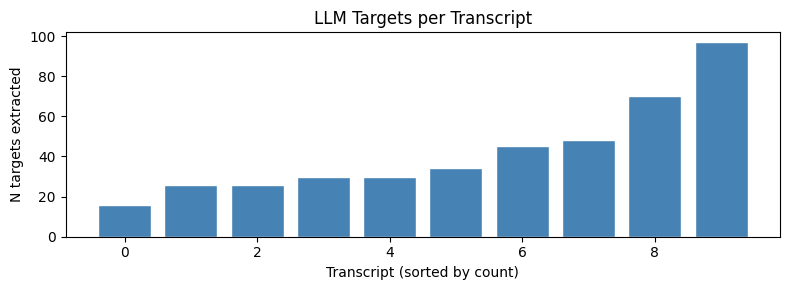

,n_targets
18671.0_2010Q1,97
24658.0_2010Q1,70
21719.0_2010Q1,48
25640.0_2010Q1,45
27060.0_2010Q1,34
25981.0_2010Q1,30
26233.0_2010Q1,30
19007.0_2010Q1,26
24732.0_2010Q1,26
26323.0_2010Q1,16


In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# Extraction statistics: targets per transcript, distribution
# ─────────────────────────────────────────────────────────────────────────────
target_counts = {
    tid: len(targets) for tid, targets in corpus_results.items()
}

stats_series = pd.Series(target_counts, name="n_targets")
print("Targets per transcript — summary statistics:")
print(stats_series.describe().to_string())

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(len(stats_series)), sorted(stats_series.values), color="steelblue", edgecolor="white")
ax.set_xlabel("Transcript (sorted by count)")
ax.set_ylabel("N targets extracted")
ax.set_title("LLM Targets per Transcript")
plt.tight_layout()
plt.show()

# Show per-transcript breakdown
display(stats_series.sort_values(ascending=False).to_frame())

---

## Section 6: Handling Long Transcripts

Real S&P 500 earnings call transcripts can exceed 30,000 tokens, well beyond a
single API call's practical budget.

* `LLMTargetExtractor._chunk_by_tokens()` splits at sentence boundaries using
  the model's `tiktoken` encoder so each chunk fits in
  `max_input_tokens_per_chunk` (default 12k for GPT-4o-mini).
* Across-chunk dedup is done in `LLMTargetExtractor._dedup()` using the
  canonical metric key from `prompts.canonicalize_metric()` — so
  "Gross Margin" / "gross margins" / "our gross margin" collapse to a single
  row.

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Find the longest transcript in the dataset
# ─────────────────────────────────────────────────────────────────────────────
lengths = {
    t["transcript_id"]: sum(len(c["text"]) for c in t["components"])
    for t in sample_transcripts
}

longest_id = max(lengths, key=lengths.get)
longest_t  = next(t for t in sample_transcripts if t["transcript_id"] == longest_id)

print(f"Longest transcript : {longest_id}")
print(f"Total chars        : {lengths[longest_id]:,}")
print(f"Components         : {len(longest_t['components'])}")
print()
for i, comp in enumerate(longest_t["components"]):
    print(f"  Component {i}: type={comp['component_type']}, chars={len(comp['text'])}")

Longest transcript : 266017.0_2018Q3
Total chars        : 1,911,271
Components         : 1436

  Component 0: type=2, chars=50
  Component 1: type=2, chars=50
  Component 2: type=2, chars=50
  Component 3: type=2, chars=50
  Component 4: type=2, chars=50
  Component 5: type=2, chars=50
  Component 6: type=2, chars=50
  Component 7: type=2, chars=1648
  Component 8: type=2, chars=2488
  Component 9: type=2, chars=2754
  Component 10: type=2, chars=2754
  Component 11: type=2, chars=1648
  Component 12: type=2, chars=2293
  Component 13: type=2, chars=2488
  Component 14: type=2, chars=2755
  Component 15: type=2, chars=2488
  Component 16: type=2, chars=2754
  Component 17: type=2, chars=1648
  Component 18: type=2, chars=1648
  Component 19: type=2, chars=2758
  Component 20: type=2, chars=2268
  Component 21: type=2, chars=2488
  Component 22: type=2, chars=2488
  Component 23: type=2, chars=50
  Component 24: type=2, chars=50
  Component 25: type=2, chars=8066
  Component 26: type=2,

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# Demonstrate token-aware chunking on the longest component.
#
# `_chunk_by_tokens` replaced the old character-count `_chunk_text`. It uses
# the model's tiktoken encoder to split at sentence boundaries while keeping
# each chunk under `max_input_tokens_per_chunk` (default 12k for gpt-4o-mini).
#
# Lazily build a local extractor if Cell 25 hasn't been run yet, so this cell
# works in isolation.
# ─────────────────────────────────────────────────────────────────────────────
if "extractor" not in dir():
    from src.llm_extraction.llm_extractor import LLMTargetExtractor
    extractor = LLMTargetExtractor(
        backend="openai",
        model="gpt-4o-mini",
        api_key=OPENAI_API_KEY,
        max_concurrent=20,
        temperature=0.0,
        max_input_tokens_per_chunk=12_000,
        request_timeout_s=90,
        max_retries=3,
        rpm_cap=4_500,
    )

longest_comp = max(longest_t["components"], key=lambda c: len(c["text"]))
long_text = longest_comp["text"]

chunks = extractor._chunk_by_tokens(long_text)

print(f"Original text  : {len(long_text):,} chars / {extractor.count_tokens(long_text):,} tokens")
print(f"Chunk budget   : {extractor.max_input_tokens_per_chunk:,} tokens")
print(f"Chunks produced: {len(chunks)}")
print()
for i, chunk in enumerate(chunks):
    n_tok = extractor.count_tokens(chunk)
    print(f"  Chunk {i+1}: {len(chunk):,} chars / {n_tok:,} tokens | "
          f"first 80 chars: {chunk[:80]!r}")

Original text  : 32,771 chars / 6,692 tokens
Chunk budget   : 12,000 tokens
Chunks produced: 1

  Chunk 1: 32,771 chars / 6,692 tokens | first 80 chars: "All right. So I think we're 3 hours into this at this point. So what I want to d"


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# Run extraction on the long transcript and verify chunk results are merged
# ─────────────────────────────────────────────────────────────────────────────
long_results = await extractor.extract_targets(long_text, longest_comp["component_type"])

print(f"Targets extracted from long transcript: {len(long_results)}")
print(f"(Across {len(chunks)} chunks, deduplicated by metric_name)")
print()
for t in long_results:
    print(f"  [{t.get('confidence','?'):6s}] {t.get('metric_name','?')}")

Targets extracted from long transcript: 10
(Across 1 chunks, deduplicated by metric_name)

  [high  ] storage growth
  [high  ] non-GAAP revenue growth
  [high  ] ISG business growth
  [high  ] server and networking growth
  [high  ] commercial client revenue growth
  [high  ] VMware segment growth
  [high  ] delevering
  [high  ] operating margin
  [high  ] revenue synergies
  [high  ] deferred revenue growth


---

## Section 7: Error Handling

The extractor implements two layers of resilience:

1. **Malformed JSON** — parsed gracefully via regex fallback; returns `[]` rather than crashing.
2. **API failures** — exponential backoff (3 attempts) then fallback to spaCy extractor if one
   was registered; otherwise returns `[]` and logs the failure.

We test both paths here.

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# Test with edge-case inputs: empty string, very short text
# These should return [] without any API call.
# ─────────────────────────────────────────────────────────────────────────────
empty_result = await extractor.extract_targets("", component_type=0)
print(f"Empty string input → targets: {empty_result}  (expected: [])")

short_result = await extractor.extract_targets("Hello.", component_type=0)
print(f"Short text input → targets: {short_result}")
print("(May return [] if LLM finds no performance targets in a single greeting sentence)")

Empty string input → targets: []  (expected: [])
Short text input → targets: []
(May return [] if LLM finds no performance targets in a single greeting sentence)


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# Test auth failure with an obviously-invalid key.
#
# Auth failures are unrecoverable, so the extractor raises immediately — we
# expect an AuthenticationError, NOT a silent empty list. This is the contract
# the LangGraph supervisor relies on to halt the corpus run on bad credentials
# instead of writing 26,000 empty rows to disk.
# ─────────────────────────────────────────────────────────────────────────────
from openai import AuthenticationError

try:
    _bad_key_text = sample_text
    _bad_key_ctype = sample_ctype
except NameError:
    _bad_key_text = (
        "Management discussed revenue growth and margin expansion in the quarter."
    )
    _bad_key_ctype = 2

bad_extractor = LLMTargetExtractor(
    backend="openai",
    model="gpt-4o-mini",
    api_key="sk-invalid-key-for-testing-0000000000000000",
    max_concurrent=1,
    max_retries=1,
    rpm_cap=None,
    request_timeout_s=10.0,
)

print("Calling extract_targets with an invalid API key (expecting AuthenticationError)...")
raised: BaseException | None = None
try:
    await bad_extractor.extract_targets(_bad_key_text, _bad_key_ctype)
except AuthenticationError as exc:
    raised = exc
except Exception as exc:
    raised = exc

print(f"\nRaised: {type(raised).__name__}: {raised}")
print(f"Telemetry: {bad_extractor.telemetry}")
assert isinstance(raised, AuthenticationError), (
    "Expected AuthenticationError from a bad key — the bad-key test would be "
    "a no-op if the extractor swallowed it."
)
assert bad_extractor.telemetry["http_failures"] >= 1
print("OK — auth failure correctly surfaced and counted in telemetry.")

Calling extract_targets with an invalid API key (expecting AuthenticationError)...

Raised: AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-inval*******************************0000. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}
Telemetry: {'total_requests': 1, 'total_input_tokens': 0, 'total_output_tokens': 0, 'total_tokens_used': 0, 'http_failures': 1, 'parse_failures': 0, 'empty_responses': 0, 'schema_invalid_drops': 0, 'retries': 0}
OK — auth failure correctly surfaced and counted in telemetry.


---

## Section 8: Cost Estimation

Before running the full corpus, let's extrapolate the per-call cost to the full S&P 500 dataset.

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# Cost extrapolation grounded in actual measurements from the pilot batch.
#
# The previous version hard-coded "2.5 calls/transcript" and arrived at ~$14
# for the full corpus. In reality, the un-aggregated extractor was issuing
# ~84 calls/transcript (one per Q&A turn, plus chunking), giving a true cost
# closer to $400-1300. This cell now derives the call ratio empirically from
# `corpus_results` (the small batch run in Section 5) instead of guessing.
# ─────────────────────────────────────────────────────────────────────────────
tel = extractor.telemetry
n_pilot_transcripts = len(corpus_results) if "corpus_results" in dir() else 1
calls_per_transcript = tel["total_requests"] / max(1, n_pilot_transcripts)
avg_input_tokens = tel["total_input_tokens"] / max(1, tel["total_requests"])
avg_output_tokens = tel["total_output_tokens"] / max(1, tel["total_requests"])

# Corpus scale per the proposal: S&P 500 × 2010-2023 quarterly = ~26,000 transcripts
TOTAL_TRANSCRIPTS = 26_000
TOTAL_CALLS = int(TOTAL_TRANSCRIPTS * calls_per_transcript)
ESTIMATED_INPUT_TOKENS = TOTAL_CALLS * avg_input_tokens
ESTIMATED_OUTPUT_TOKENS = TOTAL_CALLS * avg_output_tokens

# GPT-4o-mini pricing (USD per 1M tokens, April 2025)
PRICE_INPUT_PER_1M = 0.15
PRICE_OUTPUT_PER_1M = 0.60
cost_input_total = ESTIMATED_INPUT_TOKENS / 1_000_000 * PRICE_INPUT_PER_1M
cost_output_total = ESTIMATED_OUTPUT_TOKENS / 1_000_000 * PRICE_OUTPUT_PER_1M
estimated_cost = cost_input_total + cost_output_total

print("Empirical pilot measurements:")
print(f"  Pilot transcripts          : {n_pilot_transcripts}")
print(f"  Calls per transcript       : {calls_per_transcript:.2f}")
print(f"  Avg input  tokens / call   : {avg_input_tokens:,.0f}")
print(f"  Avg output tokens / call   : {avg_output_tokens:,.0f}")
print()
print(f"Extrapolated to full S&P 500 corpus:")
print(f"  Total transcripts          : {TOTAL_TRANSCRIPTS:,}")
print(f"  Total API calls            : {TOTAL_CALLS:,}")
print(f"  Estimated input  tokens    : {ESTIMATED_INPUT_TOKENS:,.0f}")
print(f"  Estimated output tokens    : {ESTIMATED_OUTPUT_TOKENS:,.0f}")
print()
print(f"Cost breakdown (GPT-4o-mini):")
print(f"  Input  (${PRICE_INPUT_PER_1M}/1M)         : ${cost_input_total:,.2f}")
print(f"  Output (${PRICE_OUTPUT_PER_1M}/1M)         : ${cost_output_total:,.2f}")
print(f"  TOTAL ESTIMATED COST       : ${estimated_cost:,.2f}")
print()
print(f"For comparison, GPT-4o (~33x price ratio) ~ ${estimated_cost * 33:,.2f}")

Empirical pilot measurements:
  Pilot transcripts          : 1
  Calls per transcript       : 2.00
  Avg input  tokens / call   : 4,330
  Avg output tokens / call   : 294

Extrapolated to full S&P 500 corpus:
  Total transcripts          : 26,000
  Total API calls            : 52,000
  Estimated input  tokens    : 225,160,000
  Estimated output tokens    : 15,288,000

Cost breakdown (GPT-4o-mini):
  Input  ($0.15/1M)         : $33.77
  Output ($0.6/1M)         : $9.17
  TOTAL ESTIMATED COST       : $42.95

For comparison, GPT-4o (~33x price ratio) ~ $1,417.24


---

## Section 9: Full Corpus Extraction

The cell below processes the full transcript corpus.  Given the sample dataset has ~32 rows,
this will complete quickly.  For the full S&P 500 dataset (~26,000 transcripts), expect 30–60
minutes with `max_concurrent=10` on a production API key.

> **Note**: This cell makes live API calls and incurs charges.  Verify your key and budget
> before running.  The output is saved to `data/processed/llm_targets.parquet` for downstream use.

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# Run extraction on the full available corpus with progress tracking.
#
# Uses the resumable JSONL writer: one line per finished transcript is appended
# to data/processed/llm_targets.jsonl. Re-running this cell after Ctrl-C or a
# crash skips transcripts already on disk, so no work is wasted.
#
# Performance fix: extract_transcript now aggregates components by type before
# chunking, dropping API calls/transcript from ~84 to ~3-6 (one per type, plus
# token-budget chunking on long presentations).
# ─────────────────────────────────────────────────────────────────────────────
extractor.reset_telemetry()

JSONL_PATH = DATA_PROCESSED / "llm_targets.jsonl"

n_already_done = 0
if JSONL_PATH.exists():
    with JSONL_PATH.open() as _f:
        n_already_done = sum(1 for _ in _f)

n_total = len(sample_transcripts)
n_todo = n_total - n_already_done
print(f"Total transcripts        : {n_total}")
print(f"Already in {JSONL_PATH.name} : {n_already_done}")
print(f"To process this run      : {n_todo}")

if n_todo == 0:
    print("Nothing to do — all transcripts already extracted.")
else:
    pbar = tqdm(total=n_todo, desc="LLM extraction")

    def _on_progress(done: int, total: int) -> None:
        pbar.update(1)

    t_start = time.time()
    await extractor.extract_corpus_to_jsonl(
        sample_transcripts,
        out_path=JSONL_PATH,
        max_concurrent=20,
        progress_cb=_on_progress,
    )
    elapsed = time.time() - t_start
    pbar.close()

    tel_full = extractor.telemetry
    print(f"\nCompleted in {elapsed:.1f}s ({elapsed/60:.1f} min)")
    print(f"Total requests        : {tel_full['total_requests']:,}")
    print(f"Input  tokens used    : {tel_full['total_input_tokens']:,}")
    print(f"Output tokens used    : {tel_full['total_output_tokens']:,}")
    print(f"Total tokens used     : {tel_full['total_tokens_used']:,}")
    print(f"HTTP failures         : {tel_full['http_failures']:,}")
    print(f"Empty / parse drops   : "
          f"{tel_full['empty_responses']:,} / {tel_full['schema_invalid_drops']:,}")
    print(f"Retries               : {tel_full['retries']:,}")

Total transcripts        : 929
Already in llm_targets.jsonl : 0
To process this run      : 929


LLM extraction:   0%|          | 1/929 [00:14<3:43:20, 14.44s/it]21:18:26  WARNING   src.llm_extraction.llm_extractor  Giving up on component_type=2 after 3 retries: Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o-mini in organization org-iQcwiBrmy55FknaOBZ7HjWj7 on tokens per min (TPM): Limit 200000, Used 198316, Requested 15282. Please try again in 4.079s. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}}
21:18:26  WARNING   src.llm_extraction.llm_extractor  Giving up on component_type=3 after 3 retries: Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o-mini in organization org-iQcwiBrmy55FknaOBZ7HjWj7 on tokens per min (TPM): Limit 200000, Used 196383, Requested 10866. Please try again in 2.174s. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}}
21:18:26  WARNING   src.l


Completed in 2343.9s (39.1 min)
Total requests        : 15,466
Input  tokens used    : 5,251,977
Output tokens used    : 184,899
Total tokens used     : 5,436,876
HTTP failures         : 3,343
Empty / parse drops   : 0 / 0
Retries               : 14,403


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# Flatten the resumable JSONL into a parquet for downstream notebooks.
#
# transcript_id is the canonical "{company_id}_{year}Q{quarter}" key written by
# build_transcript_list(). We parse it back into (company_id, fiscalyear,
# fiscalquarter) so the merge with spaCy in Section 10 is on identical keys.
# ─────────────────────────────────────────────────────────────────────────────
import re as _re

_TID_RX = _re.compile(r"^(?P<company_id>[^_]+)_(?P<fiscalyear>\d{4})Q(?P<fiscalquarter>\d)$")

all_llm_rows: list[dict] = []
with JSONL_PATH.open() as _f:
    for line in _f:
        line = line.strip()
        if not line:
            continue
        rec = json.loads(line)
        tid = rec["transcript_id"]
        m = _TID_RX.match(tid)
        if m:
            company_id = m.group("company_id").rstrip(".0")
            fy = int(m.group("fiscalyear"))
            fq = int(m.group("fiscalquarter"))
            quarter = f"{fy}Q{fq}"
        else:
            company_id, fy, fq, quarter = tid, None, None, ""
        for t in rec.get("targets", []):
            all_llm_rows.append({
                "transcript_id": tid,
                "company_id": company_id,
                "fiscalyear": fy,
                "fiscalquarter": fq,
                "quarter": quarter,
                **t,
            })

llm_targets_df = pd.DataFrame(all_llm_rows)
if "fiscalyear" in llm_targets_df.columns:
    llm_targets_df["fiscalyear"] = llm_targets_df["fiscalyear"].astype("Int64")
    llm_targets_df["fiscalquarter"] = llm_targets_df["fiscalquarter"].astype("Int64")

out_path = DATA_PROCESSED / "llm_targets.parquet"
llm_targets_df.to_parquet(out_path, index=False)

print(f"Saved {len(llm_targets_df):,} target rows from {llm_targets_df['transcript_id'].nunique()} transcripts")
print(f"  -> {out_path}")
print(f"Columns: {list(llm_targets_df.columns)}")
llm_targets_df.head()

Saved 2,744 target rows from 493 transcripts
  -> /Users/tiantian/Downloads/CU Material/S3/5293/Project/LLM Project/Data/processed/llm_targets.parquet
Columns: ['transcript_id', 'company_id', 'fiscalyear', 'fiscalquarter', 'quarter', 'metric_name', 'raw_text', 'numerical_value', 'trend_direction', 'unit', 'time_horizon', 'is_financial', 'confidence', 'canonical_name']


,transcript_id,company_id,fiscalyear,fiscalquarter,quarter,metric_name,raw_text,numerical_value,trend_direction,unit,time_horizon,is_financial,confidence,canonical_name
0,33926.0_2010Q2,33926,2010,2,2010Q2,comparable store sales,forecast a comparable store sales gain of 3% to 4%,NaN,up,percent,forward,False,high,comparable sale store
1,33926.0_2010Q2,33926,2010,2,2010Q2,earnings per share,earnings per share of $0.95 to $0.99,NaN,up,dollars,forward,True,high,earning per share
2,33926.0_2010Q2,33926,2010,2,2010Q2,total sales,Total sales are expected to grow about 7% to 8%,NaN,up,percent,forward,True,high,sale total
3,33926.0_2010Q2,33926,2010,2,2010Q2,operating margin,Operating margin for the second quarter is expected to b...,NaN,up,percent,forward,True,high,margin operating
4,33926.0_2010Q2,33926,2010,2,2010Q2,fiscal 2010 EPS,fiscal 2010 EPS is projected to grow 16% to 20% to $4.11...,NaN,up,dollars,forward,True,high,2010 eps fiscal


---

## Section 10: Quality Assessment

Compare LLM extraction counts with spaCy extraction counts across all transcripts to identify
systematic differences and flag transcripts that warrant manual review.

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# Compare LLM vs spaCy extractions on the SAME (firm, year, quarter) keys.
#
# Key methodology fix vs the previous version of this cell:
#   * INNER join on (company_id, fiscalyear, fiscalquarter) — the previous
#     outer-join + fillna(0) created 1,000+ phantom rows where one of the two
#     extractors had no coverage by construction, contaminating every
#     diagnostic in the next cell.
#   * Both methods are now normalised through canonicalize_metric() so
#     "Gross Margin" and "gross margins" collapse to the same key on both
#     sides — the count comparison reflects real semantic disagreement, not
#     surface-form variation.
# ─────────────────────────────────────────────────────────────────────────────
from src.llm_extraction.prompts import canonicalize_metric

spacy_targets_df = pd.read_parquet(DATA_PROCESSED / "spacy_targets.parquet")


def _norm_company(x: object) -> str:
    s = str(x).strip()
    return s[:-2] if s.endswith(".0") else s


# spaCy side: build canonical per-firm-quarter sets (drop empty / unmatchable rows).
spacy_norm = (
    spacy_targets_df
    .assign(
        company_id=lambda d: d["companyid"].map(_norm_company),
        fiscalyear=lambda d: d["fiscalyear"].astype("Int64"),
        fiscalquarter=lambda d: d["fiscalquarter"].astype("Int64"),
        canonical_name=lambda d: (
            d.get("normalized_text", d.get("target_text", pd.Series([], dtype=str)))
             .astype(str).map(canonicalize_metric)
        ),
    )
    .loc[lambda d: d["canonical_name"].astype(bool)]
)
spacy_sets = (
    spacy_norm.groupby(["company_id", "fiscalyear", "fiscalquarter"])["canonical_name"]
              .apply(lambda s: frozenset(s))
              .reset_index(name="spacy_set")
)
spacy_sets["spacy_count"] = spacy_sets["spacy_set"].map(len)

# LLM side: parse keys from transcript_id and use the canonical_name we already
# annotate at extraction time (LLMTargetExtractor._dedup).
_TID_RX = re.compile(r"^(?P<company_id>[^_]+)_(?P<fiscalyear>\d{4})Q(?P<fiscalquarter>\d)$")
parsed = llm_targets_df["transcript_id"].str.extract(_TID_RX)

llm_norm = llm_targets_df.assign(
    company_id=parsed["company_id"].map(_norm_company),
    fiscalyear=pd.to_numeric(parsed["fiscalyear"], errors="coerce").astype("Int64"),
    fiscalquarter=pd.to_numeric(parsed["fiscalquarter"], errors="coerce").astype("Int64"),
    canonical_name=lambda d: (
        d["canonical_name"] if "canonical_name" in d.columns
        else d["metric_name"].astype(str).map(canonicalize_metric)
    ),
).loc[lambda d: d["canonical_name"].astype(bool)]

llm_sets = (
    llm_norm.dropna(subset=["company_id", "fiscalyear", "fiscalquarter"])
            .groupby(["company_id", "fiscalyear", "fiscalquarter"])["canonical_name"]
            .apply(lambda s: frozenset(s))
            .reset_index(name="llm_set")
)
llm_sets["llm_count"] = llm_sets["llm_set"].map(len)

# INNER join — only firm-quarters covered by both pipelines.
counts_merged = spacy_sets.merge(
    llm_sets, on=["company_id", "fiscalyear", "fiscalquarter"], how="inner",
)
counts_merged["spacy_count"] = counts_merged["spacy_count"].astype(int)
counts_merged["llm_count"] = counts_merged["llm_count"].astype(int)
counts_merged["difference"] = counts_merged["llm_count"] - counts_merged["spacy_count"]
counts_merged["overlap_count"] = counts_merged.apply(
    lambda r: len(r["spacy_set"] & r["llm_set"]), axis=1
)
counts_merged["llm_only_count"] = counts_merged.apply(
    lambda r: len(r["llm_set"] - r["spacy_set"]), axis=1
)
counts_merged["spacy_only_count"] = counts_merged.apply(
    lambda r: len(r["spacy_set"] - r["llm_set"]), axis=1
)
denom = counts_merged[["spacy_count", "llm_count"]].max(axis=1).replace(0, pd.NA)
counts_merged["jaccard"] = counts_merged["overlap_count"] / denom

print(f"spaCy firm-quarters with output : {len(spacy_sets):,}")
print(f"LLM   firm-quarters with output : {len(llm_sets):,}")
print(f"INNER-join firm-quarters        : {len(counts_merged):,}")
print()
print("Sample of inner-joined comparison rows:")
display(
    counts_merged[
        ["company_id", "fiscalyear", "fiscalquarter",
         "spacy_count", "llm_count", "overlap_count",
         "llm_only_count", "spacy_only_count", "jaccard"]
    ].head(15)
)

spaCy firm-quarters with output : 929
LLM   firm-quarters with output : 493
INNER-join firm-quarters        : 493

Sample of inner-joined comparison rows:


,company_id,fiscalyear,fiscalquarter,spacy_count,llm_count,overlap_count,llm_only_count,spacy_only_count,jaccard
0,11857151,2016,4,8,2,0,2,8,0.0
1,252588,2010,1,2,3,0,3,2,0.0
2,252588,2010,2,5,1,0,1,5,0.0
3,252588,2011,3,2,5,0,5,2,0.0
4,252588,2012,1,4,3,0,3,4,0.0
5,252588,2012,2,6,8,0,8,6,0.0
6,252588,2012,3,5,8,0,8,5,0.0
7,252588,2012,4,5,7,0,7,5,0.0
8,252588,2013,1,3,5,0,5,3,0.0
9,252588,2013,2,1,5,0,5,1,0.0


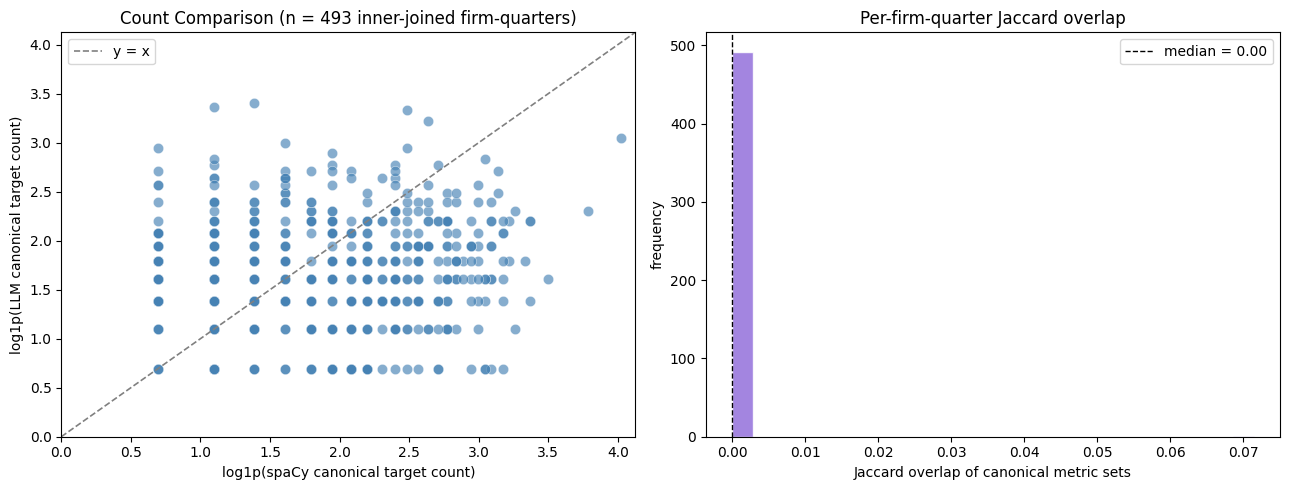

Inner-joined firm-quarters     : 493
Pearson  (counts)              : 0.090
Spearman (counts)              : 0.068
Median Jaccard (set overlap)   : 0.000
Mean   diff (LLM - spaCy)      : -2.47
Median diff (LLM - spaCy)      : -1.00
% LLM > spaCy / equal / less   : 35.7% / 5.9% / 58.4%


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# Diagnostic comparison on the inner-joined panel.
# Left  : log1p scatter of LLM vs spaCy counts (n = inner-join rows).
# Right : Jaccard overlap of canonical metric sets per firm-quarter.
# ─────────────────────────────────────────────────────────────────────────────
plot_df = counts_merged.copy()
if plot_df.empty:
    print("No overlapping firm-quarters between spaCy and LLM panels.")
    print("Run the LLM extraction (Cell 40) on the spaCy panel first.")
else:
    x = np.log1p(plot_df["spacy_count"])
    y = np.log1p(plot_df["llm_count"])

    pearson = plot_df[["spacy_count", "llm_count"]].corr(method="pearson").iloc[0, 1]
    spearman = plot_df[["spacy_count", "llm_count"]].corr(method="spearman").iloc[0, 1]
    mean_diff = plot_df["difference"].mean()
    median_diff = plot_df["difference"].median()
    median_jaccard = plot_df["jaccard"].dropna().median()
    pct_above = (plot_df["difference"] > 0).mean() * 100
    pct_below = (plot_df["difference"] < 0).mean() * 100
    pct_equal = (plot_df["difference"] == 0).mean() * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    ax1.scatter(x, y, alpha=0.65, s=55, color="steelblue",
                edgecolors="white", linewidth=0.4)
    max_log = float(max(x.max(), y.max()) + 0.1)
    ax1.plot([0, max_log], [0, max_log], "--", color="gray", linewidth=1.2,
             label="y = x")
    ax1.set_xlim(0, max_log)
    ax1.set_ylim(0, max_log)
    ax1.set_xlabel("log1p(spaCy canonical target count)")
    ax1.set_ylabel("log1p(LLM canonical target count)")
    ax1.set_title(f"Count Comparison (n = {len(plot_df):,} inner-joined firm-quarters)")
    ax1.legend(loc="upper left")

    ax2.hist(plot_df["jaccard"].dropna(), bins=25, color="mediumpurple",
             edgecolor="white", alpha=0.85)
    ax2.axvline(median_jaccard, color="black", linestyle="--", linewidth=1,
                label=f"median = {median_jaccard:.2f}")
    ax2.set_xlabel("Jaccard overlap of canonical metric sets")
    ax2.set_ylabel("frequency")
    ax2.set_title("Per-firm-quarter Jaccard overlap")
    ax2.legend()

    plt.tight_layout()
    plt.show()

    print(f"Inner-joined firm-quarters     : {len(plot_df):,}")
    print(f"Pearson  (counts)              : {pearson:.3f}")
    print(f"Spearman (counts)              : {spearman:.3f}")
    print(f"Median Jaccard (set overlap)   : {median_jaccard:.3f}")
    print(f"Mean   diff (LLM - spaCy)      : {mean_diff:+.2f}")
    print(f"Median diff (LLM - spaCy)      : {median_diff:+.2f}")
    print(f"% LLM > spaCy / equal / less   : "
          f"{pct_above:.1f}% / {pct_equal:.1f}% / {pct_below:.1f}%")

In [30]:
print(counts_merged[["llm_count", "spacy_count", "overlap_count",
                     "llm_only_count", "spacy_only_count", "jaccard"]].describe())
print(f"\nFirm-quarters with zero LLM overlap : "
      f"{(counts_merged['overlap_count'] == 0).sum()}")
print(f"Firm-quarters with full agreement   : "
      f"{(counts_merged['jaccard'] == 1.0).sum()}")

        llm_count  spacy_count  overlap_count  llm_only_count  \
count  493.000000   493.000000     493.000000      493.000000   
mean     5.565923     8.032454       0.002028        5.563895   
std      4.019543     6.718117       0.045038        4.015528   
min      1.000000     1.000000       0.000000        1.000000   
25%      3.000000     3.000000       0.000000        3.000000   
50%      5.000000     6.000000       0.000000        5.000000   
75%      7.000000    11.000000       0.000000        7.000000   
max     29.000000    55.000000       1.000000       29.000000   

       spacy_only_count     jaccard  
count        493.000000  493.000000  
mean           8.030426    0.000145  
std            6.719185    0.003217  
min            1.000000    0.000000  
25%            3.000000    0.000000  
50%            6.000000    0.000000  
75%           11.000000    0.000000  
max           55.000000    0.071429  

Firm-quarters with zero LLM overlap : 492
Firm-quarters with full agree

In [31]:
# Coverage diagnostic — separate from the inner-joined comparison above.
# This shows where each pipeline has unique coverage so we can tell scope-mismatch
# (one pipeline didn't run on this firm-quarter) apart from real disagreement
# (both ran but extracted different metrics).
spacy_keys = set(map(tuple, spacy_sets[["company_id", "fiscalyear", "fiscalquarter"]].values))
llm_keys = set(map(tuple, llm_sets[["company_id", "fiscalyear", "fiscalquarter"]].values))

print(f"Firm-quarters with spaCy output only : {len(spacy_keys - llm_keys):,}")
print(f"Firm-quarters with LLM   output only : {len(llm_keys - spacy_keys):,}")
print(f"Firm-quarters with BOTH (inner-join) : {len(spacy_keys & llm_keys):,}")
print(f"Firm-quarters total                  : {len(spacy_keys | llm_keys):,}")

Firm-quarters with spaCy output only : 436
Firm-quarters with LLM   output only : 0
Firm-quarters with BOTH (inner-join) : 493
Firm-quarters total                  : 929


In [32]:
# Top firm-quarters by absolute disagreement — best targets for manual review.
# We use |difference| but only on the inner-joined panel so we know both
# pipelines actually saw this transcript.
top_disagreements = counts_merged.reindex(
    counts_merged["difference"].abs().nlargest(20).index
).sort_values("difference")

display(top_disagreements[
    ["company_id", "fiscalyear", "fiscalquarter",
     "spacy_count", "llm_count", "difference",
     "overlap_count", "jaccard"]
])

,company_id,fiscalyear,fiscalquarter,spacy_count,llm_count,difference,overlap_count,jaccard
417,364744,2014,4,55,20,-35,0,0.0
423,364744,2016,4,43,9,-34,0,0.0
431,364744,2018,4,32,4,-28,0,0.0
464,365602,2013,4,28,3,-25,0,0.0
470,365602,2015,3,25,2,-23,0,0.0
127,280123,2018,4,23,1,-22,0,0.0
271,33926,2010,1,27,5,-22,0,0.0
490,378088,2022,1,23,3,-20,0,0.0
299,33926,2018,1,21,1,-20,0,0.0
155,299095,2011,3,28,8,-20,0,0.0


In [55]:
# ─────────────────────────────────────────────────────────────────────────────
# Drill-down: for the top-disagreement firm-quarter, show which canonical
# metrics each pipeline emitted (LLM-only, spaCy-only, shared). This is
# the diff a human annotator would actually score.
# ─────────────────────────────────────────────────────────────────────────────
if not counts_merged.empty:
    counts_merged["abs_diff"] = counts_merged["difference"].abs()
    pick = counts_merged.sort_values("abs_diff", ascending=False).iloc[0]
    sp_set = pick["spacy_set"]
    llm_set = pick["llm_set"]
    print(f"Firm-quarter under review: company_id={pick['company_id']} "
          f"{int(pick['fiscalyear'])}Q{int(pick['fiscalquarter'])}")
    print(f"  spaCy targets         : {pick['spacy_count']}")
    print(f"  LLM   targets         : {pick['llm_count']}")
    print(f"  Overlap               : {pick['overlap_count']}")
    print(f"  Jaccard               : {pick['jaccard']:.3f}")
    print(f"\nSHARED ({len(sp_set & llm_set)}):")
    for m in sorted(sp_set & llm_set)[:25]:
        print(f"   = {m}")
    print(f"\nLLM-only ({len(llm_set - sp_set)}):")
    for m in sorted(llm_set - sp_set)[:25]:
        print(f"   + {m}")
    print(f"\nspaCy-only ({len(sp_set - llm_set)}):")
    for m in sorted(sp_set - llm_set)[:25]:
        print(f"   - {m}")
    print()
    print("Interpretation: 'LLM-only' rows are typically the qualitative or")
    print("trend-based targets spaCy NER misses. 'spaCy-only' rows are usually")
    print("noise (numeric tokens with no real KPI structure) — manual review")
    print("on a few of these is the basis of the F1 evaluation in §4 of the proposal.")
else:
    print("No inner-joined firm-quarters to review yet.")

Top transcripts by absolute disagreement between LLM and spaCy:
company_id  quarter  spacy_count  llm_count  difference
    364744        4          289          0        -289
     33926        1          250          0        -250
    378088        4          207          0        -207
    378088        3          201          0        -201
    378088        2          186          0        -186
    280123        1          174          0        -174
    299095        1          172          0        -172
    299095        3          170          0        -170
    378088        1          168          0        -168
     33926        3          166          0        -166

These are the highest-value transcripts for manual annotation — understanding
WHY the two extractors diverge here will guide further prompt tuning.
